In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 1. Load Data

In [2]:
df = pd.read_csv("../data/final/cleaned_issues.csv")
df["full_text"] = df.get("clean_title", "").fillna("") + " " + df.get("clean_body", "").fillna("")

df["orig_len"] = df["full_text"].apply(lambda x: len(str(x)))
df["summ_len"] = df["summary"].fillna("").apply(lambda x: len(str(x)))
print(f"Loaded {len(df)} summaries.")

Loaded 852 summaries.


## 2. Compression Ratio


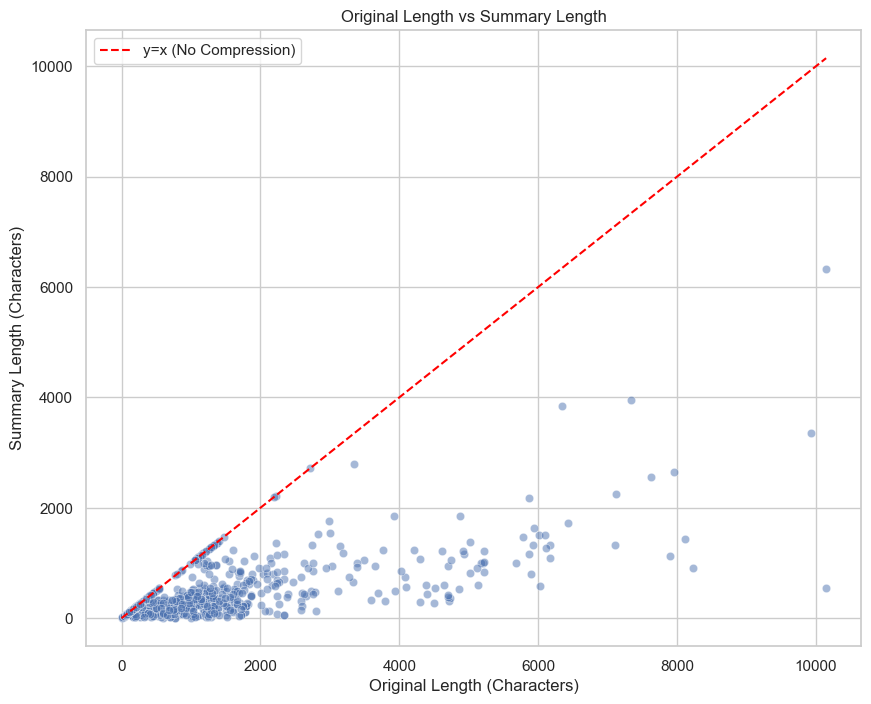

In [3]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x="orig_len", y="summ_len", data=df, alpha=0.5)

# Adding y=x line to represent the identity baseline
max_val = max(df["orig_len"].max(), df["summ_len"].max())
plt.plot([0, max_val], [0, max_val], color="red", linestyle="--", label="y=x (No Compression)")

plt.title("Original Length vs Summary Length")
plt.xlabel("Original Length (Characters)")
plt.ylabel("Summary Length (Characters)")
plt.legend()
plt.show()

## 3. Heuristic Flags


In [4]:
identical = df[df["summ_len"] == df["orig_len"]].shape[0]
empty = df[df["summ_len"] == 0].shape[0]
too_short = df[df["summ_len"] < 10].shape[0]

print(f"Issues Identical to Original: {identical} (Usually due to very short text)")
print(f"Empty Summaries: {empty}")
print(f"Too Short (<10 chars): {too_short}")

Issues Identical to Original: 209 (Usually due to very short text)
Empty Summaries: 0
Too Short (<10 chars): 1


## 4. Side-by-side Inspection


In [5]:
compressed_samples = df[df["summ_len"] < (df["orig_len"] * 0.4)].sample(3, random_state=42)

for idx, row in compressed_samples.iterrows():
    print("="*80)
    print(f"ORIGINAL (Len: {row['orig_len']}):\n{row['full_text']}\n")
    print(f"SUMMARY (Len: {row['summ_len']}):\n{row['summary']}\n")

ORIGINAL (Len: 545):
test plan: auto mode router refs: [url] - [x] anyos - [x] anyos complexity: 2 [create issue]( [url] --- context this iteration we've implemented support for intelligent routing for auto based on user queries. test steps 1. add this [inline code] to your settings. 2. use auto and sned various prompts / do work 3. inspect the chat debug view for auto mode router entries ensure everything seems to work as you'd expect, you should see an entry per turn as well as a decision on whether or not we believe this is requires a reasoning model or not

SUMMARY (Len: 208):
test plan: auto mode router refs: [url] - [x] anyos - [x] anyos complexity: 2 [create issue]( [url] --- context this iteration we've implemented support for intelligent routing for auto based on user queries.

ORIGINAL (Len: 5926):
[bug] torch profile not working on b300 gpu 🐛 describe the bug my env info: gpu: b300 physical machine cuda version: driver version: 580.105.08 cuda version: 13.0 docker container:

## 5. Model Comparision

In [7]:
# --- Compare TextRank vs BART summaries (fixed version) ---

from nlp.summarizer import Summarizer
from transformers import pipeline
import pandas as pd

# Sample small subset (keep small for speed)
sample_df = df.sample(5, random_state=42).copy()

# Safe text extraction
texts = (
    sample_df.get("clean_title", pd.Series([""] * len(sample_df))).fillna("") + " " +
    sample_df.get("clean_body", pd.Series([""] * len(sample_df))).fillna("")
)

# --- TextRank ---
textrank_model = Summarizer(model="textrank")
textrank_summaries = [textrank_model.summarize(t) for t in texts]

# --- BART (with dynamic length fix) ---
bart = pipeline("summarization", model="facebook/bart-large-cnn")

bart_summaries = []
for text in texts:
    words = len(text.split())
    
    # Dynamic length control
    max_len = max(30, int(words * 0.6))
    min_len = max(10, int(words * 0.3))
    
    try:
        summary = bart(
            text,
            max_length=max_len,
            min_length=min_len,
            do_sample=False
        )[0]["summary_text"]
    except:
        summary = text[:200]  # fallback
    
    bart_summaries.append(summary)

# --- Store results ---
sample_df["original_len"] = texts.apply(len)
sample_df["textrank_summary"] = textrank_summaries
sample_df["bart_summary"] = bart_summaries
sample_df["textrank_len"] = sample_df["textrank_summary"].apply(len)
sample_df["bart_len"] = sample_df["bart_summary"].apply(len)

# --- Display ---
sample_df[[
    "original_len",
    "textrank_len",
    "bart_len",
    "textrank_summary",
    "bart_summary"
]].head()

Device set to use cpu


,original_len,textrank_len,bart_len,textrank_summary,bart_summary
66,1103,1103,251,rate limit kicking in for no reason type: bug ...,bug rate limit kicks in even with very basic ...
434,501,95,194,can't import tensorflow standalone code to rep...,Can't import tensorflow standalone code to rep...
198,1343,262,283,"vs code version: code 1.109.5 ( [hash] , 2026-...","i increased the amount and de=selected ""stop"" ..."
212,460,460,191,extension download fails: content-encoding: gz...,extension download fails: content-encoding: g...
651,279,101,120,you have to explicitely import it: [inline cod...,There are two minor issues regarding [url] 1. ...


In [8]:
# --- Compute compression ratios ---

textrank_ratio = (sample_df["textrank_len"] / sample_df["original_len"]).mean()
bart_ratio = (sample_df["bart_len"] / sample_df["original_len"]).mean()

print("Average Compression Ratio:")
print(f"TextRank: {textrank_ratio:.3f}")
print(f"BART    : {bart_ratio:.3f}")

Average Compression Ratio:
TextRank: 0.549
BART    : 0.334


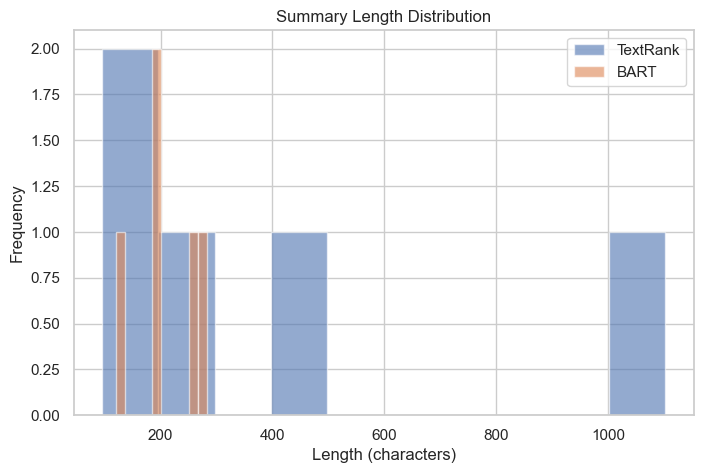

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(sample_df["textrank_len"], alpha=0.6, label="TextRank")
plt.hist(sample_df["bart_len"], alpha=0.6, label="BART")

plt.title("Summary Length Distribution")
plt.xlabel("Length (characters)")
plt.ylabel("Frequency")
plt.legend()

plt.show()

## Interpretation

From the summary length distribution, BART produces shorter and more consistent summaries, while TextRank shows a wider range of lengths and retains more content.

Although BART achieves better compression, TextRank preserves more original information and avoids altering technical details. Given the importance of accuracy and determinism in this system, TextRank is preferred for the pipeline.